In [ ]:
import pandas as pd
import numpy as np

data_set = pd.read_csv("drive/MyDrive/neural/adult.data")
data_set = data_set.map(lambda x: x.strip() if isinstance(x, str) else x)

In [ ]:
x =  data_set.iloc[:,:-1].values
y =  data_set.iloc[:,-1].values

feature = data_set.keys().map(lambda x: x.strip() if isinstance(x, str) else x)



from sklearn.impute import SimpleImputer

cat_col_indices = [1,3,5,6,7,8, 12, 13]
for i in cat_col_indices:
    x[:, i] = np.where(x[:, i] == '?', np.nan, x[:, i])
    x[:, i] = SimpleImputer(strategy='most_frequent').fit_transform(x[:, i].reshape(-1,1)).ravel()


In [ ]:
import numpy as np
from collections import Counter

cat_col_indices = [1,3,5,6,7,8, 12, 13]

for i in cat_col_indices:
    col = x[:, i]

    valid_vals = col[col != '?']

    counts = Counter(valid_vals)
    most_frequent = counts.most_common(1)[0][0]

    col[col == '?'] = most_frequent

    x[:, i] = col

In [ ]:
feature

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'salary'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoders = []
for i in range(x.shape[1]):
    le = LabelEncoder()
    x[:, i] = le.fit_transform(x[:, i])
    encoders.append(le)

In [ ]:
import numpy as np

x_encoded = np.empty_like(x, dtype=int)
encoders = []

for i in range(x.shape[1]):
    col = x[:, i]
    unique_vals = np.unique(col)
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    x_encoded[:, i] = np.array([mapping[val] for val in col])
    encoders.append(mapping)

x = x_encoded

In [ ]:
x

array([[22, 6, 2671, ..., 39, 38, 0],
       [33, 5, 2926, ..., 12, 38, 0],
       [21, 3, 14086, ..., 39, 38, 0],
       ...,
       [41, 3, 7883, ..., 39, 38, 0],
       [5, 3, 12881, ..., 19, 38, 0],
       [35, 4, 17825, ..., 39, 38, 1]], dtype=object)

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
st_x= MinMaxScaler()
x = st_x.fit_transform(x)

In [ ]:
import numpy as np

x_scaled = np.empty_like(x, dtype=float)

for i in range(x.shape[1]):
    col = x[:, i].astype(float)
    col_min = col.min()
    col_max = col.max()
    x_scaled[:, i] = (col - col_min) / (col_max - col_min)

x = x_scaled

In [ ]:
x

array([[0.30555556, 0.85714286, 0.12338892, ..., 0.        , 0.41935484,
        0.95      ],
       [0.45833333, 0.71428571, 0.13516885, ..., 0.        , 0.12903226,
        0.95      ],
       [0.29166667, 0.42857143, 0.65071372, ..., 0.        , 0.41935484,
        0.95      ],
       ...,
       [0.56944444, 0.42857143, 0.36416132, ..., 0.        , 0.41935484,
        0.95      ],
       [0.06944444, 0.42857143, 0.59504781, ..., 0.        , 0.20430108,
        0.95      ],
       [0.48611111, 0.57142857, 0.82343974, ..., 0.        , 0.41935484,
        0.95      ]])

In [ ]:
import numpy as np

n_samples, n_features = x.shape
corr_matrix = np.zeros((n_features, n_features))

x = x.astype(float)

means = np.mean(x, axis=0)
stds = np.std(x, axis=0, ddof=0)

for i in range(n_features):
    for j in range(n_features):
        cov = np.sum((x[:, i] - means[i]) * (x[:, j] - means[j])) / n_samples
        corr_matrix[i, j] = cov / (stds[i] * stds[j])

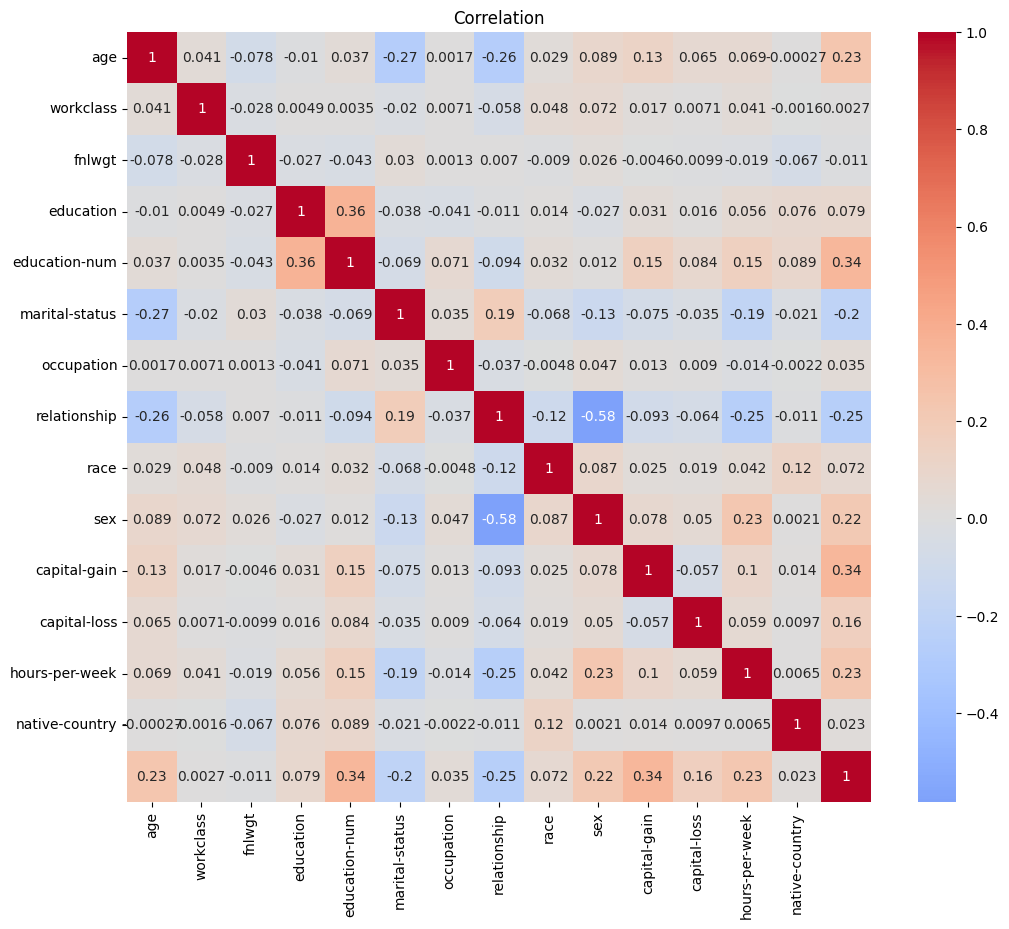

In [ ]:
corr_matrix = np.corrcoef(x, rowvar=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, xticklabels=feature[:-1], yticklabels=feature[:-1])
plt.title('Correlation')
plt.show()

Tree:

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

df = pd.DataFrame(x, columns=feature[:-1])
df['Class'] = y

X = df.drop('Class', axis=1)
y = df['Class']

clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X, y)

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("DecisionTreeClassifier")
print(importances)

DecisionTreeClassifier
fnlwgt            0.211370
relationship      0.196090
age               0.132453
capital-gain      0.105543
education-num     0.101664
hours-per-week    0.071345
occupation        0.059772
capital-loss      0.035640
workclass         0.034519
native-country    0.013395
education         0.013109
race              0.011533
marital-status    0.010055
sex               0.003514
dtype: float64


In [ ]:
import numpy as np
import pandas as pd

def entropy(y):
    _, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

def gain_ratio(feature, target):
    H_Y = entropy(target)
    IG = -1
    SI = -1
    GR = -1

    if isinstance(feature[0], int):
        MAX_THRESHOLDS = 100

        quantiles = np.linspace(0, 1, MAX_THRESHOLDS)[1:-1]
        thresholds = np.quantile(feature, quantiles)
        thresholds = np.unique(thresholds)

        splits = []
        for median in thresholds:
            left = target[feature <= median]
            right = target[feature > median]
            subsets = [left, right]
            probs = [len(left)/len(target), len(right)/len(target)]

            # Information Gain
            H_XY = sum(p * entropy(s) for p, s in zip(probs, subsets))
            IG = H_Y - H_XY

            # Split Info
            SI = -sum(p * np.log2(p) for p in probs)

            # Gain Ratio
            GR = IG / SI

            splits.append((median, GR, IG, SI))

        best = sorted(splits, key=lambda x: x[1], reverse=True)[0]
        median, GR, IG, SI = best

    else:
        subsets = [target[feature == v] for v in set(feature)]
        probs = [len(s)/len(target) for s in subsets]

        H_XY = sum(p * entropy(s) for p, s in zip(probs, subsets))

        # Information Gain
        H_XY = sum(p * entropy(s) for p, s in zip(probs, subsets))
        IG = H_Y - H_XY

        # Split Info
        SI = -sum(p * np.log2(p) for p in probs)

        # Gain Ratio
        GR = IG / SI

    return IG, SI, GR

gr_table = {}
for col in range(x.shape[1]):
    IG, SI, GR = gain_ratio(x[:, col], y)
    gr_table[feature[col]] = {'IG': IG, 'SI': SI, 'GainRatio': GR}
    #print(col)

gr_df = pd.DataFrame(gr_table).T.sort_values('GainRatio', ascending=False)
print("Custom")
print(gr_df)

/tmp/ipython-input-1188602850.py:34: RuntimeWarning: divide by zero encountered in log2
  SI = -sum(p * np.log2(p) for p in probs)
/tmp/ipython-input-1188602850.py:34: RuntimeWarning: invalid value encountered in scalar multiply
  SI = -sum(p * np.log2(p) for p in probs)


Custom
                      IG        SI  GainRatio
capital-gain    0.070146  0.220838   0.317635
education-num   0.024857  0.196263   0.126651
capital-loss    0.022985  0.195956   0.117297
age             0.063269  0.660132   0.095844
marital-status  0.156528  1.833649   0.085364
relationship    0.165366  2.154424   0.076756
hours-per-week  0.040501  0.857863   0.047211
sex             0.037171  0.915736   0.040592
education       0.093591  2.931351   0.031928
occupation      0.075913  3.353203   0.022639
workclass       0.018116  1.358865   0.013332
native-country  0.008694  0.816638   0.010646
race            0.008378  0.798741   0.010489
fnlwgt          0.000137  0.142608   0.000960


[6, 8, 2, 6, 3, 5, 4, 2, 7, 8, 8, 1, 8, 2, 6, 1, 1, 3, 0, 7, 5, 4, 2, 3, 7, 3, 2, 5, 4, 6, 8, 1, 4, 1, 7, 6, 7, 9, 2, 1, 0, 8, 1, 8, 6, 7, 3, 2, 3, 0, 9, 2, 0, 8, 7, 5, 4, 8, 4, 7, 4, 7, 9, 9, 2, 5, 7, 5, 6, 9, 0, 2, 9, 5, 9, 9, 5, 5, 9, 0, 3, 6, 8, 6, 2, 2, 3, 8, 3, 7, 3, 0, 8, 6, 0, 6, 7, 3, 3, 0, 2, 6, 7, 5, 0, 5, 6, 8, 3, 6, 9, 6, 8, 7, 2, 8, 3, 4, 7, 9, 4, 7, 3, 7, 0, 1, 9, 4, 1, 6, 6, 8, 2, 0, 7, 7, 9, 6, 2, 4, 9, 4, 3, 7, 3, 3, 7, 0, 0, 5, 0, 6, 1, 9, 7, 3, 6, 8, 2, 4, 1, 2, 5, 3, 6, 9, 8, 2, 9, 0, 5, 6, 5, 9, 6, 1, 4, 1, 6, 5, 8, 7, 0, 3, 5, 5, 0, 7, 9, 8, 7, 0, 9, 9, 1, 7, 4, 0, 7, 6, 2, 6, 5, 5, 7, 6, 4, 6, 8, 5, 2, 6, 1, 3, 1, 8, 3, 8, 4, 5, 6, 3, 6, 9, 5, 2, 6, 3, 2, 6, 7, 6, 3, 5, 0, 2, 5, 2, 4, 5, 2, 3, 2, 3, 8, 7, 9, 3, 5, 8, 3, 5, 7, 7, 2, 1, 5, 3, 6, 5, 8, 3, 4, 9, 4, 5, 9, 3, 7, 3, 0, 7, 8, 3, 6, 9, 0, 6, 5, 3, 9, 8, 6, 8, 2, 2, 0, 2, 7, 2, 2, 1, 8, 0, 8, 5, 7, 8, 5, 9, 0, 9, 8, 9, 2, 3, 3, 8, 8, 0, 3, 9, 3, 5, 9, 0, 6, 0, 7, 6, 8, 4, 1, 3, 2, 7, 2, 7, 9, 5, 6, 9, 3, 

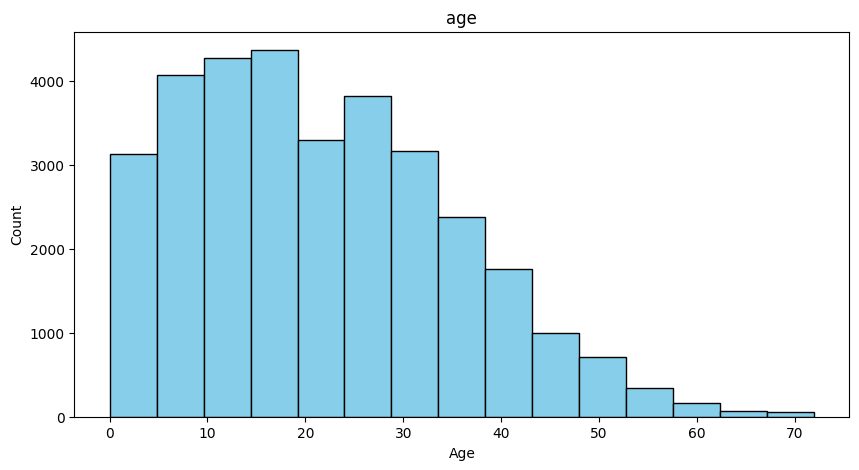

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

age = x[:, 0]
#print([a for a in age if a < 10])
target = y


plt.figure(figsize=(10,5))
plt.hist(age, bins=15, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('age')

sorted_idx = np.argsort(age)
age_sorted = age[sorted_idx]

thresholds = (age_sorted[:-1] + age_sorted[1:]) / 2
thresholds = np.unique(thresholds)

plt.show()